In [6]:
import pandas as pd
import numpy as np

# keep_default_na=False : sinon pandas transforme le texte "None" en valeur manquante
raw = pd.read_csv("diabetic_data.csv", keep_default_na=False, low_memory=False)

## 1. Business Understanding

**Problématique :** à partir des informations disponibles à la sortie, peut-on repérer les patients diabétiques à risque de réadmission à 30 jours, comprendre quels profils existent, et orienter le suivi vers les bons patients ? Dans nos données, **11,2 %** des séjours sont suivis d'une réadmission à 30 jours.

### 1.1 État de l'art

**Ce qui existe déjà**
- **Enjeu :** les réadmissions précoces sont coûteuses et nuisibles au patient. Aux États-Unis, des programmes de pénalités (type **HRRP**) sanctionnent les hôpitaux dont les taux sont trop élevés.
- **Ce jeu de données :** *Diabetes 130-US Hospitals (1999-2008)* provient de l'étude de Strack et al. (2014). Elle examine l'effet de la mesure de l'HbA1c sur la réadmission, par régression logistique. Elle conclut que cet effet dépend du diagnostic principal.
- **Modèles prédictifs :** la littérature sur la prédiction des réadmissions rapporte en général un pouvoir prédictif modeste (AUC ≈ 0,6 à 0,7). Les variables les plus citées sont l'historique d'hospitalisations, la durée de séjour et les comorbidités.
- **Équité :** un bon score global peut cacher des performances plus faibles selon l'âge, le genre ou l'origine des patients.

**Où se situe notre travail**
- Nous reprenons la question de la réadmission, mais en la traitant de bout en bout : **profils** de patients, **score de risque**, **facteurs explicatifs**, **priorisation** selon la capacité de l'équipe, **tableau de bord** et **audit d'équité**.
- Un AUC proche de 0,95 serait un signal de fuite de données, pas une réussite.

*Références : Strack B. et al., « Impact of HbA1c measurement on hospital readmission rates », BioMed Research International, 2014, doi:10.1155/2014/781670.*

### 1.2 Objectifs métier (BO)

| BO | Objectif métier | Idée |
|---|---|---|
| **BO1** | Identifier les différents profils de patients | décrire des profils types avec un nom parlant (« séjour express », « revenant »…) |
| **BO2** | Étudier la réadmission hospitalière | donner à chaque patient un score de risque avant la sortie (feu tricolore) |
| **BO3** | Identifier les caractéristiques associées à la réadmission | comprendre quels patients et quels séjours reviennent, pour en informer les médecins |
| **BO4** | Identifier les patients nécessitant une attention particulière | concentrer les appels de suivi là où l'impact est maximal |
| **BO5** | Tableau de bord qualité et suivi du diabète | fournir à la direction des indicateurs par profil, âge, destination de sortie et prise en charge du diabète |
| **BO6** | IA de confiance | s'assurer que le modèle est explicable et équitable |

### 1.3 Objectifs Data Science (DSO)

| BO | Objectif Data Science (DSO) |
|---|---|
| **BO1** | regrouper les patients en profils homogènes et interprétables, puis mesurer le taux de réadmission de chaque profil |
| **BO2** | prédire `readmitted_30` à partir des informations connues à la sortie |
| **BO3** | mesurer l'influence de chaque variable sur le risque et la traduire en messages compréhensibles par les médecins |
| **BO4** | classer les patients par score, choisir le nombre de patients suivis selon la capacité de l'équipe et mesurer le gain par rapport à un ciblage au hasard |
| **BO5** | calculer des indicateurs agrégés et tester si l'HbA1c, les changements de traitement et l'insuline sont liés à la réadmission |
| **BO6** | comparer les performances du modèle selon le genre, la race et la tranche d'âge |

**Cible :** `readmitted_30 = 1` si `readmitted == "<30"`, sinon 0 (définition des programmes de type HRRP). Limite : on perd la distinction « réadmis après 30 jours » (31 % des séjours).

**Critères de succès :** *utile* (le score capte nettement plus de réadmissions qu'un ciblage au hasard), *compréhensible* (profils et facteurs en langage médical), *juste* (pas d'écart marqué entre sous-groupes), *réaliste* (AUC ≈ 0,6 à 0,7).

## 2. Data Understanding
### 2.1 Chargement et dimensions : `.shape`

In [13]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)       # afficher toutes les colonnes (le fichier en a 50)
RS = 42

raw = pd.read_csv("diabetic_data.csv", low_memory=False, keep_default_na=False)   # keep_default_na=False : voir remarque ci-dessous
print("Dimensions (lignes, colonnes) :", raw.shape)
print(f"Séjours : {raw.shape[0]:,} | variables : {raw.shape[1]}".replace(",", " "))
print(f"Mémoire occupée : {raw.memory_usage(deep=True).sum()/1e6:.0f} Mo")

Dimensions (lignes, colonnes) : (101766, 50)
Séjours : 101 766 | variables : 50
Mémoire occupée : 206 Mo


**Constat :** le fichier contient **101 766 séjours** décrits par **50 variables**. C'est un volume confortable (assez de lignes pour apprendre sans sur-apprentissage) mais assez large pour que le tri des colonnes soit nécessaire.

**Choix de lecture : on lit d'abord le fichier tel quel (sans `na_values`)** pour voir comment les valeurs manquantes sont réellement codées. Dans ce jeu de données, l'absence d'information est écrite `"?"` (et non `NaN`), ce qui est un piège classique : le cours précise que *« missing values must be marked with NaN »* avant toute imputation.

**Deuxième piège : `keep_default_na=False`.** Par défaut, `pandas` convertit automatiquement le texte `"None"` en `NaN`. Or dans `A1Cresult` et `max_glu_serum`, `"None"` est une **vraie modalité** (« examen non réalisé », voir plus bas). Sans ce paramètre, on confondrait « non testé » avec « donnée absente » sans s'en apercevoir.

### 2.2 Aperçu des données : `.head()`

In [14]:
raw.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


**Ce que l'on voit sur les premières lignes :**
- **Un séjour par ligne** (`encounter_id`), rattaché à un patient (`patient_nbr`) : un même patient peut donc apparaître plusieurs fois.
- Des **`?`** à la place des informations absentes (`weight`, `payer_code`, parfois `medical_specialty`, `diag_2`, `diag_3`).
- Des **codes numériques** (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`) dont le sens est dans `IDS_mapping.csv`.
- L'**âge** n'est pas un nombre mais une tranche (`[0-10)`, `[10-20)`…).
- Une grande majorité de colonnes de **médicaments** valant `No`.
- La cible brute `readmitted` prend trois valeurs : `NO`, `>30`, `<30`.

### 2.3 Structure et types : `.info()`

In [9]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

**Constat :**
- **50 colonnes : 13 numériques (`int64`) et 37 textuelles.** Le comptage affiche « 101766 non-null » partout : pour `pandas`, **il n'y a aucun `NaN`**. C'est trompeur, car les vrais manquants sont écrits `"?"` (voir 2.5).
- **Type ne veut pas dire nature.** Trois colonnes numériques sont en réalité des **codes** (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`) et deux sont des **identifiants** (`encounter_id`, `patient_nbr`) : leur moyenne n'a aucun sens. À l'inverse, `age` est textuel mais **ordinal** (tranches ordonnées).
- **23 colonnes de médicaments** textuelles à 4 modalités (`No`, `Steady`, `Up`, `Down`).

**Dictionnaire des variables (regroupées par thème) :**

| Thème | Variables | Nature |
|---|---|---|
| Identifiants | `encounter_id`, `patient_nbr` | identifiants (non prédictifs) |
| Démographie | `race`, `gender`, `age`, `weight` | catégorielles (âge ordinal) |
| Admission et sortie | `admission_type_id`, `admission_source_id`, `discharge_disposition_id` | codes à traduire avec `IDS_mapping.csv` |
| Administratif | `payer_code`, `medical_specialty` | catégorielles |
| Intensité du séjour | `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses` | numériques (comptages) |
| Historique de soins (année précédente) | `number_outpatient`, `number_emergency`, `number_inpatient` | numériques (comptages) |
| Diagnostics | `diag_1`, `diag_2`, `diag_3` | codes ICD-9 (centaines de modalités) |
| Examens | `max_glu_serum`, `A1Cresult` | catégorielles (`None` = non réalisé) |
| Traitements | 23 molécules, `change`, `diabetesMed` | catégorielles |
| **Cible** | `readmitted` | `NO` / `>30` / `<30` |

**Point de vigilance (fuite de données) :** hormis `readmitted`, toutes les variables sont connues **au plus tard à la sortie** : on peut donc les utiliser pour prédire sans tricher.

### 2.4 Statistiques descriptives : `.describe()`
On sépare les variables **numériques** (moyenne, quartiles, extrêmes) des variables **textuelles** (nombre de modalités, modalité dominante).

In [15]:
print("=== Variables numériques ===")
display(raw.describe().T.round(2))
print("\n=== Variables textuelles (nombre de modalités, modalité dominante) ===")
display(raw.select_dtypes(exclude="number").describe().T.head(12))

=== Variables numériques ===


,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.020000e+00,1.450000e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.720000e+00,5.280000e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.750000e+00,4.060000e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.400000e+00,2.990000e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.310000e+01,1.967000e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.340000e+00,1.710000e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602000e+01,8.130000e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.700000e-01,1.270000e+00,0.0,0.0,0.0,0.000000e+00,42.0



=== Variables textuelles (nombre de modalités, modalité dominante) ===


,count,unique,top,freq
race,101766,6,Caucasian,76099
gender,101766,3,Female,54708
age,101766,10,[70-80),26068
weight,101766,10,?,98569
payer_code,101766,18,?,40256
medical_specialty,101766,73,?,49949
diag_1,101766,717,428,6862
diag_2,101766,749,276,6752
diag_3,101766,790,250,11555
max_glu_serum,101766,4,None,96420


**Constat sur les variables numériques :**
- **Les identifiants et les codes sont à ignorer** dans cette lecture (`encounter_id`, `patient_nbr`, `admission_type_id`, `discharge_disposition_id`, `admission_source_id`) : leurs moyennes n'ont aucun sens.
- **Les compteurs d'historique sont très asymétriques** : `number_outpatient` a une moyenne de 0,37, mais son 3ᵉ quartile est **0** et son maximum **42** ; `number_emergency` va jusqu'à **76** ; `number_inpatient` jusqu'à **21**. Dès que la médiane est très inférieure à la moyenne et au maximum, on est face à une **queue lourde à droite**.
- **Intensité du séjour** : `time_in_hospital` va de **1 à 14 jours** (médiane 4) avec un plafond net à 14 (variable tronquée) ; `num_lab_procedures` a une médiane de 44 (max 132) ; `num_medications` une médiane de 15 (max 81) ; `number_diagnoses` va de 1 à 16, avec une médiane de 8 mais un 3ᵉ quartile déjà à **9**, signe d'un **plafond de saisie** (pic à 9).
- Aucun minimum négatif ni valeur impossible : les valeurs extrêmes sont **élevées mais plausibles**, il ne s'agit pas d'erreurs de saisie.

**Constat sur les variables textuelles :**
- `diag_1`, `diag_2`, `diag_3` comptent **717, 749 et 790 codes différents** : inutilisables tels quels (voir regroupement ICD-9 en 4.2.1) ; `medical_specialty` en compte 73 et `payer_code` 18.
- `race` a 6 modalités dont `?` ; `gender` en a **3**, dont une valeur invalide (`Unknown/Invalid`, 3 lignes).
- `age` : la tranche dominante est `[70-80)` (≈ 26 % des séjours) ; la population est âgée.
- `weight` : la valeur la plus fréquente est `?` (**98 569 lignes sur 101 766**), la colonne est quasi vide.
- `A1Cresult` et `max_glu_serum` : la modalité dominante est `None`, c'est-à-dire « **examen non réalisé** ».

### 2.5 Valeurs manquantes : `.isna()` et comptage des `"?"`
Deux niveaux de lecture : (1) les `NaN` que `pandas` voit, (2) les manquants **déguisés** que l'on doit chercher soi-même.

Valeurs NaN vues par pandas (isna) : 0

Colonnes avec des '?' :


,nb de '?',% de '?'
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


Colonnes sans aucun manquant : 43 sur 50


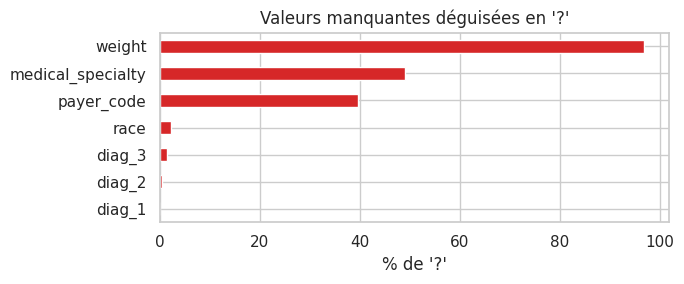

In [16]:
print("Valeurs NaN vues par pandas (isna) :", int(raw.isna().sum().sum()))

# (2) manquants déguisés : '?' (comptage et pourcentage par colonne)
n_q = (raw == "?").sum()
miss = pd.DataFrame({"nb de '?'": n_q, "% de '?'": (n_q/len(raw)*100).round(2)})
miss = miss[miss["nb de '?'"] > 0].sort_values("% de '?'", ascending=False)
print("\nColonnes avec des '?' :"); display(miss)
print("Colonnes sans aucun manquant :", int((n_q==0).sum()), "sur", raw.shape[1])

fig, ax = plt.subplots(figsize=(7,3))
miss["% de '?'"].plot.barh(ax=ax, color="tab:red"); ax.set_xlabel("% de '?'"); ax.invert_yaxis(); ax.set_title("Valeurs manquantes déguisées en '?'")
plt.tight_layout(); plt.show()

**Constat :**
- `isna()` renvoie **0** : à première vue, le fichier est complet. C'est **faux** : `pandas` ne reconnaît pas `"?"` comme manquant.
- En cherchant les `"?"`, on trouve **7 colonnes** concernées : `weight` (**96,9 %**, inexploitable), `medical_specialty` (**49 %**), `payer_code` (**40 %**), puis `race` (2,2 %), `diag_3` (1,4 %), `diag_2` (0,4 %) et `diag_1` (0,02 %).
- Les 43 autres colonnes n'ont aucun manquant.

### Les « faux manquants » cliniques
Les colonnes `A1Cresult` et `max_glu_serum` contiennent la valeur texte `"None"`. Ce n'est **pas** une donnée manquante au sens technique : cela signifie **« l'examen n'a pas été réalisé »**, ce qui est une information clinique.

In [17]:
for c in ["A1Cresult","max_glu_serum"]:
    print(c, raw[c].value_counts().to_dict())
raw["readmitted_30"] = (raw.readmitted=="<30").astype(int)
print("\nCible readmitted :", raw.readmitted.value_counts().to_dict())
print("Taux de réadmission < 30 j :", round(raw.readmitted_30.mean()*100,2), "%")
print("\nTaux de réadmission selon le résultat HbA1c :")
print((raw.groupby("A1Cresult").readmitted_30.mean()*100).round(1).to_string())

A1Cresult {'None': 84748, '>8': 8216, 'Norm': 4990, '>7': 3812}
max_glu_serum {'None': 96420, 'Norm': 2597, '>200': 1485, '>300': 1264}

Cible readmitted : {'NO': 54864, '>30': 35545, '<30': 11357}
Taux de réadmission < 30 j : 11.16 %

Taux de réadmission selon le résultat HbA1c :
A1Cresult
>7      10.0
>8       9.9
None    11.4
Norm     9.7


**Constat clé :** 83 % des séjours n'ont **pas** de mesure d'HbA1c. Garder la modalité `None` comme catégorie **« NotTested »** est plus honnête que de l'imputer ; l'absence de test est elle-même une information, que l'on réutilisera pour construire `clinical_inertia` (section 5).

### Structure des séjours : un patient, plusieurs lignes

In [18]:
vc = raw.patient_nbr.value_counts()
print("Patients uniques :", len(vc), "| séjours :", len(raw))
print("Part de patients avec plus d'un séjour :", round((vc>1).mean()*100,1), "% | max :", vc.max())
print("Doublons de lignes entières :", raw.duplicated().sum(), "| encounter_id dupliqués :", raw.encounter_id.duplicated().sum())

Patients uniques : 71518 | séjours : 101766
Part de patients avec plus d'un séjour : 23.5 % | max : 40
Doublons de lignes entières : 0 | encounter_id dupliqués : 0


**Constat important :** ~23 % des patients apparaissent plusieurs fois (jusqu'à 40 séjours). Cela a **une conséquence méthodologique majeure** : si on découpait train/test au hasard **ligne par ligne**, un même patient serait des deux côtés et le modèle « reconnaîtrait » ses habitudes. **On découpera donc par patient** (section 6).

### Colonnes constantes ou quasi constantes (médicaments)

In [19]:
drugs = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride','acetohexamide','glipizide','glyburide','tolbutamide',
         'pioglitazone','rosiglitazone','acarbose','miglitol','troglitazone','tolazamide','examide','citoglipton','insulin',
         'glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone']
share_no = (raw[drugs]=="No").mean().sort_values(ascending=False)
print((share_no*100).round(2).to_string())

citoglipton                 100.00
examide                     100.00
acetohexamide               100.00
metformin-pioglitazone      100.00
glimepiride-pioglitazone    100.00
metformin-rosiglitazone     100.00
troglitazone                100.00
glipizide-metformin          99.99
tolbutamide                  99.98
miglitol                     99.96
tolazamide                   99.96
chlorpropamide               99.92
acarbose                     99.70
nateglinide                  99.31
glyburide-metformin          99.31
repaglinide                  98.49
glimepiride                  94.90
rosiglitazone                93.75
pioglitazone                 92.80
glyburide                    89.53
glipizide                    87.53
metformin                    80.36
insulin                      46.56


**Constat :** `examide` et `citoglipton` valent **toujours « No »** (variance nulle, aucune information) ; 6 autres molécules sont à 99,9 % « No » ou plus. Seules **`insulin`** (≈ 53 % de prescription) et **`metformin`** (≈ 20 %) sont fréquentes ; viennent ensuite glipizide (12 %), glyburide (10 %), pioglitazone (7 %), rosiglitazone (6 %) et glimepiride (5 %), les 12 autres étant sous 1,5 %.
**Choix :** garder `insulin` et `metformin` individuellement (les deux traitements de référence, les plus prescrits), et résumer **toutes** les molécules par deux compteurs (nombre utilisées / nombre modifiées), section 4.3. C'est un compromis : on perd le détail des molécules moins fréquentes, on gagne ~20 colonnes peu stables.